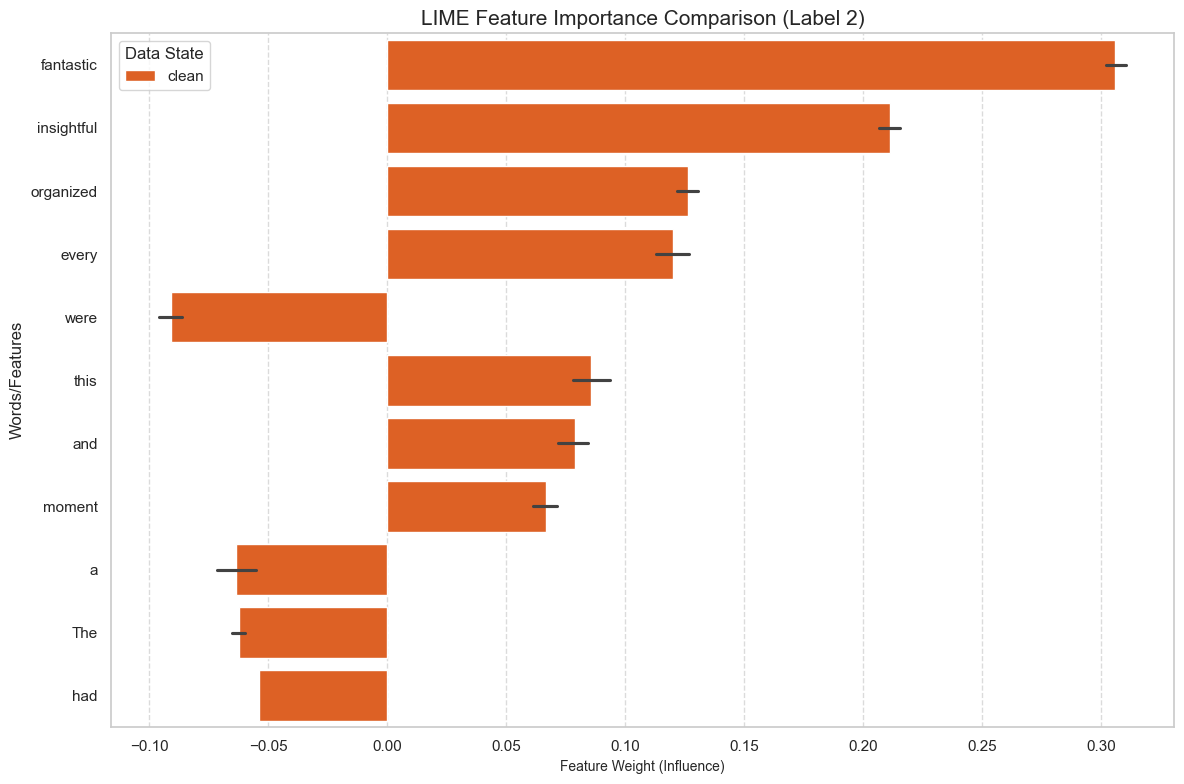

In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
file_path = "/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_stability_experiment.csv"
df_clean = pd.read_csv(file_path)

# Filter for the specific label you want to visualize (e.g., Label 2)
# and take the most recent run if you have multiple seeds/samples
target_label = 2
plot_df = df_clean[df_clean['label'] == target_label].copy()

# Create the Visualization
plt.figure(figsize=(12, 8))

# We use a barplot to compare 'weight' across different 'features'
# hue='data_state' will put Clean and Biased bars side-by-side
sns.barplot(
    data=plot_df,
    x='weight',
    y='feature',
    hue='data_state',
    palette={'clean':'#fb5607'} # Blue for clean, Red for biased
)

plt.title(f'LIME Feature Importance Comparison (Label {target_label})', fontsize=15)
plt.xlabel('Feature Weight (Influence)', fontsize=10)
plt.ylabel('Words/Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Data State')
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/lime_stability_experiment.png",bbox_inches='tight')
plt.tight_layout()
plt.show()


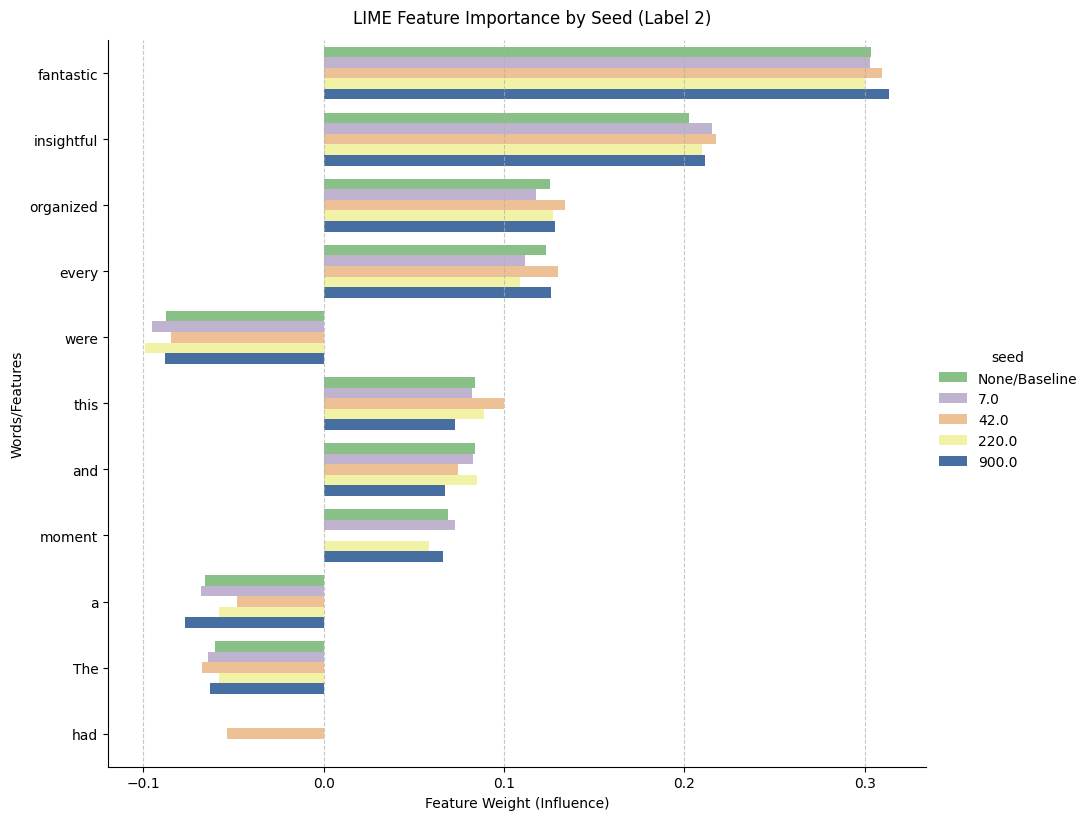

In [165]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for the specific label
target_label = 2
# Ensure type consistency
plot_df = df_clean[df_clean['label'].astype(str) == str(target_label)].copy()

if plot_df.empty:
    print(f"Error: No data found for label {target_label}. Check your CSV values.")
else:
    # Handle the 'None' seed visually
    # Replacing actual None/NaN with a string so Seaborn can categoricalize it
    plot_df['seed'] = plot_df['seed'].fillna('None/Baseline').astype(str)

    custom_colors = ["#84a98c", "#fb5607", "#003f88", "#d90429", "#F333FF"]
    # Create the Visualization
    g = sns.catplot(
        data=plot_df,
        kind='bar',
        x='weight',
        y='feature',
        hue='seed',  # Seeds are now the side-by-side bars
        height=8,
        aspect=1.2,
        palette= 'Accent',
        legend_out=True,
        #linestyle='--',
    )
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    g.fig.suptitle(f'LIME Feature Importance by Seed (Label {target_label})', y=1.02, fontsize=12)
    g.set_axis_labels('Feature Weight (Influence)', 'Words/Features')
    plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/lime_stability_experiment_across_seeds.png",bbox_inches='tight')
    plt.show()

In [236]:

#  Group by the label (metric) and feature (word) to see how
# the 'weight' (importance) changes across different seeds/samples
stability_stats = df_clean.groupby(['label', 'feature'])['weight'].agg(['mean', 'std']).reset_index()

# Calculate Relative Standard Deviation (Coefficient of Variation)
# This helps compare stability across features with different weight scales
stability_stats['relative_std'] = stability_stats['std'] / (stability_stats['mean'].abs() + 1e-9)

# Aggregate to the label level to see which "label" is most stable overall
overall_stability = stability_stats.groupby('label').agg({
    'std': 'median',
    'relative_std': 'median'
}).rename(columns={'std': 'median_abs_variation', 'relative_std': 'median_rel_variation'})

print("Stability Comparison (Lower values = More Stable):")
print(overall_stability.sort_values('median_rel_variation'))

Stability Comparison (Lower values = More Stable):
       median_abs_variation  median_rel_variation
label                                            
2                   0.00604                0.0708


In [237]:
# Group by 'feature' (and 'label' if applicable) to see how weights/ranks vary across seeds
stability_stats = df.groupby(['label', 'feature'])['weight'].agg(['mean', 'std']).reset_index()

# Calculate Relative Stability (Coefficient of Variation)
# We add 1e-9 to avoid division by zero
stability_stats['relative_std'] = stability_stats['std'] / (stability_stats['mean'].abs() + 1e-9)

# Aggregate by Label to see which category has the most stable feature importance
overall_stability = stability_stats.groupby('label').agg({
    'std': 'median',
    'relative_std': 'median'
}).rename(columns={
    'std': 'median_abs_variation',
    'relative_std': 'median_rel_variation'
})

print("Stability Comparison (Across Seeds):")
print(overall_stability)

Stability Comparison (Across Seeds):
       median_abs_variation  median_rel_variation
label                                            
2                  0.005928              0.063465


In [239]:
# Grouping by 'feature' to see how stable each feature's importance is across seeds
stability_stats = df_clean.groupby(['feature'])['weight'].agg(['mean', 'std']).reset_index()

# Calculate relative stability (Coefficient of Variation)
stability_stats['relative_std'] = stability_stats['std'] / (stability_stats['mean'].abs() + 1e-9)

# Aggregate to get a single  for the whole model
overall_stability = stability_stats.agg({
    'std': 'median',
    'relative_std': 'median'
})

print("Model Stability Overview:")
print(overall_stability)

Model Stability Overview:
std             0.00604
relative_std    0.07080
dtype: float64


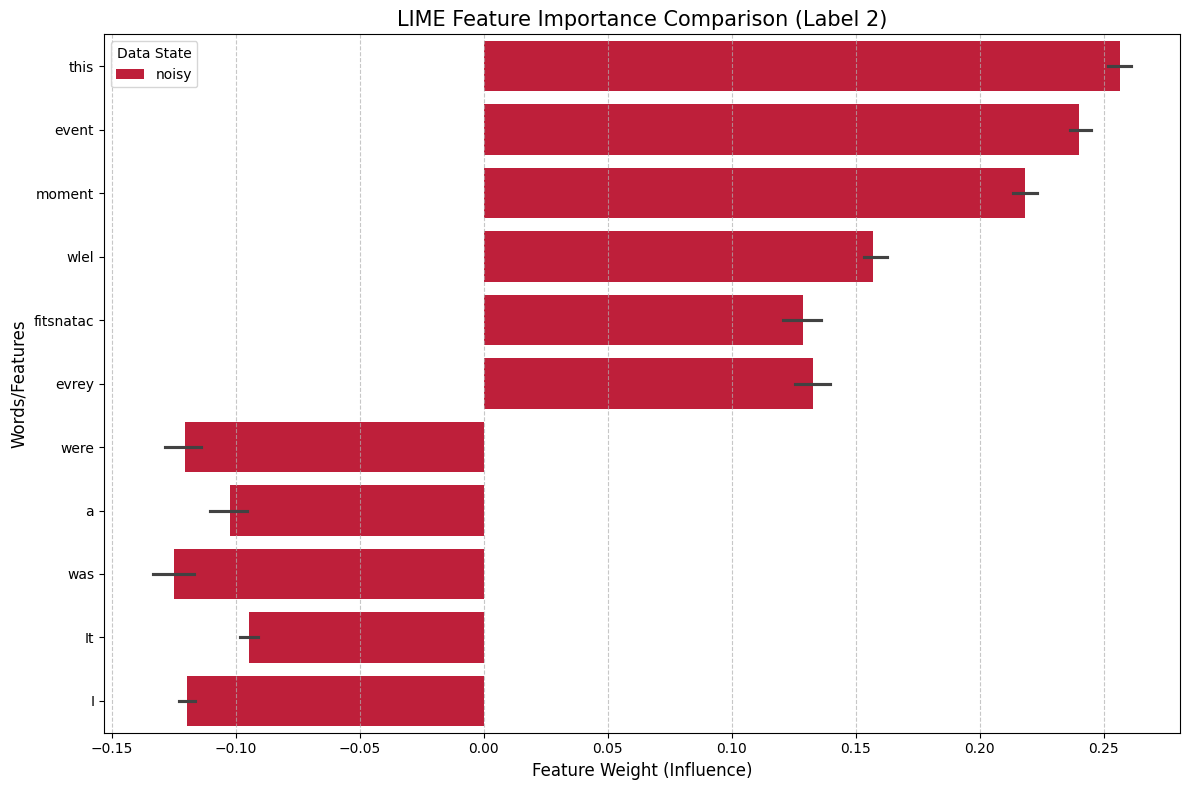

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
file_path = "/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/perturb_lime_stability_experiment.csv"
df_noisy = pd.read_csv(file_path)

# Filter for the specific label you want to visualize (e.g., Label 2)
# and take the most recent run if you have multiple seeds/samples
target_label = 2
plot_noisy_df = df_noisy[df_noisy['label'] == target_label].copy()

# Create the Visualization
plt.figure(figsize=(12, 8))

# We use a barplot to compare 'weight' across different 'features'
# hue='data_state' will put Clean and Biased bars side-by-side
sns.barplot(
    data=plot_noisy_df,
    x='weight',
    y='feature',
    hue='data_state',
    palette={'noisy': '#d90429', 'biased': '#450920'} # Blue for clean, Red for biased
)

plt.title(f'LIME Feature Importance Comparison (Label {target_label})', fontsize=15)
plt.xlabel('Feature Weight (Influence)', fontsize=12)
plt.ylabel('Words/Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Data State')

plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/perturb_lime_stability_experiment.png",bbox_inches='tight')

plt.tight_layout()
plt.show()


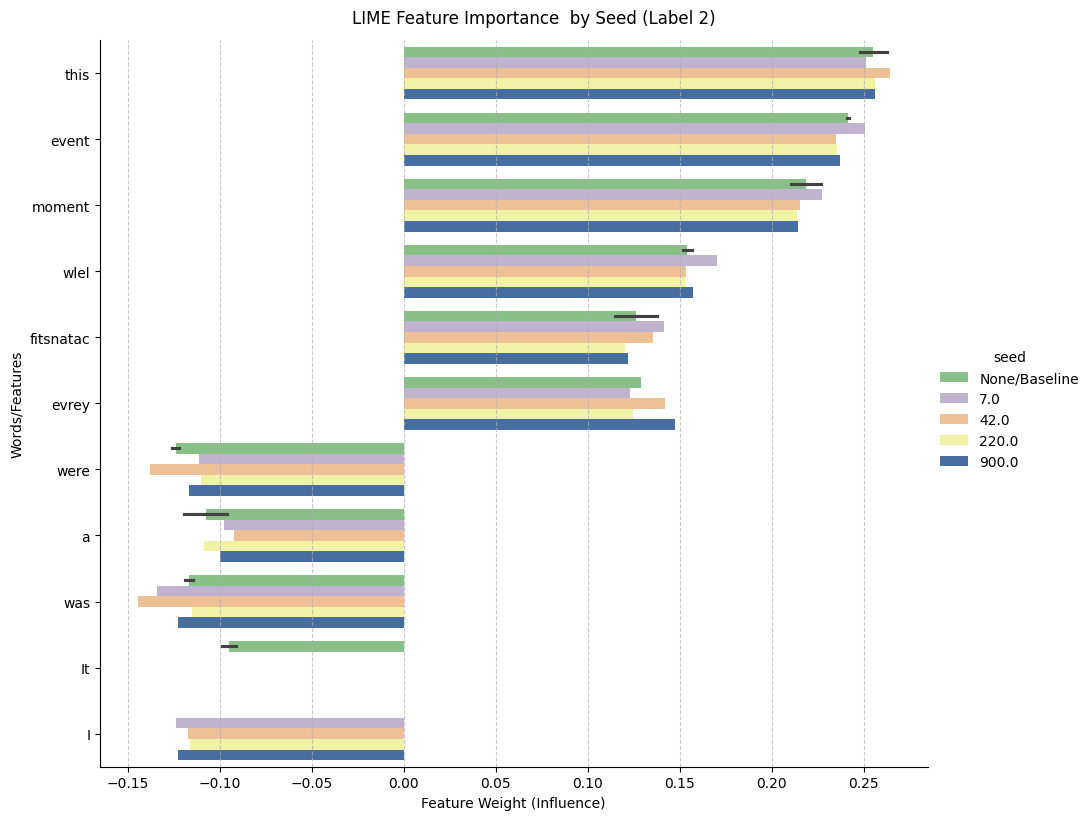

In [172]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for the specific label
target_label = 2
# Ensure type consistency (e.g., if label was saved as a string)
plot_noisy_df= df_noisy[df_noisy['label'].astype(str) == str(target_label)].copy()

if plot_df.empty:
    print(f"Error: No data found for label {target_label}. Check your CSV values.")
else:
    # Handle the 'None' seed visually
    # Replacing actual None/NaN with a string so Seaborn can categoricalize it
    plot_noisy_df['seed'] = plot_noisy_df['seed'].fillna('None/Baseline').astype(str)

    custom_colors = ["#003049", "#669bbc", "#fdf0d5", "#450920", "#F333FF"]
    # Create the Visualization
    g = sns.catplot(
        data=plot_noisy_df,
        kind='bar',
        x='weight',
        y='feature',
        hue='seed',  # Seeds are now the side-by-side bars
        height=8,
        aspect=1.2,
        palette= 'Accent'
, # Using a standard palette for multiple seeds
        #legend_out=True,
    )
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    g.fig.suptitle(f'LIME Feature Importance  by Seed (Label {target_label})', y=1.02)
    g.set_axis_labels('Feature Weight (Influence)', 'Words/Features')
    plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/noisy_lime_stability_experiment_across_seeds.png",bbox_inches='tight')
    plt.show()

In [238]:

#  Group by the label (metric) and feature (word) to see how
# the 'weight' (importance) changes across different seeds/samples
stability_stats = df_noisy.groupby(['label', 'feature'])['weight'].agg(['mean', 'std']).reset_index()

# Calculate Relative Standard Deviation (Coefficient of Variation)
# This helps compare stability across features with different weight scales
stability_stats['relative_std'] = stability_stats['std'] / (stability_stats['mean'].abs() + 1e-9)

# Aggregate to the label level to see which label is most stable overall
overall_stability = stability_stats.groupby('label').agg({
    'std': 'median',
    'relative_std': 'median'
}).rename(columns={'std': 'median_abs_variation', 'relative_std': 'median_rel_variation'})

print("Stability Comparison (Lower values = More Stable):")
print(overall_stability.sort_values('median_rel_variation'))

Stability Comparison (Lower values = More Stable):
       median_abs_variation  median_rel_variation
label                                            
2                  0.007269              0.053799


## LIME Sobol evaluation

<Figure size 1400x800 with 0 Axes>

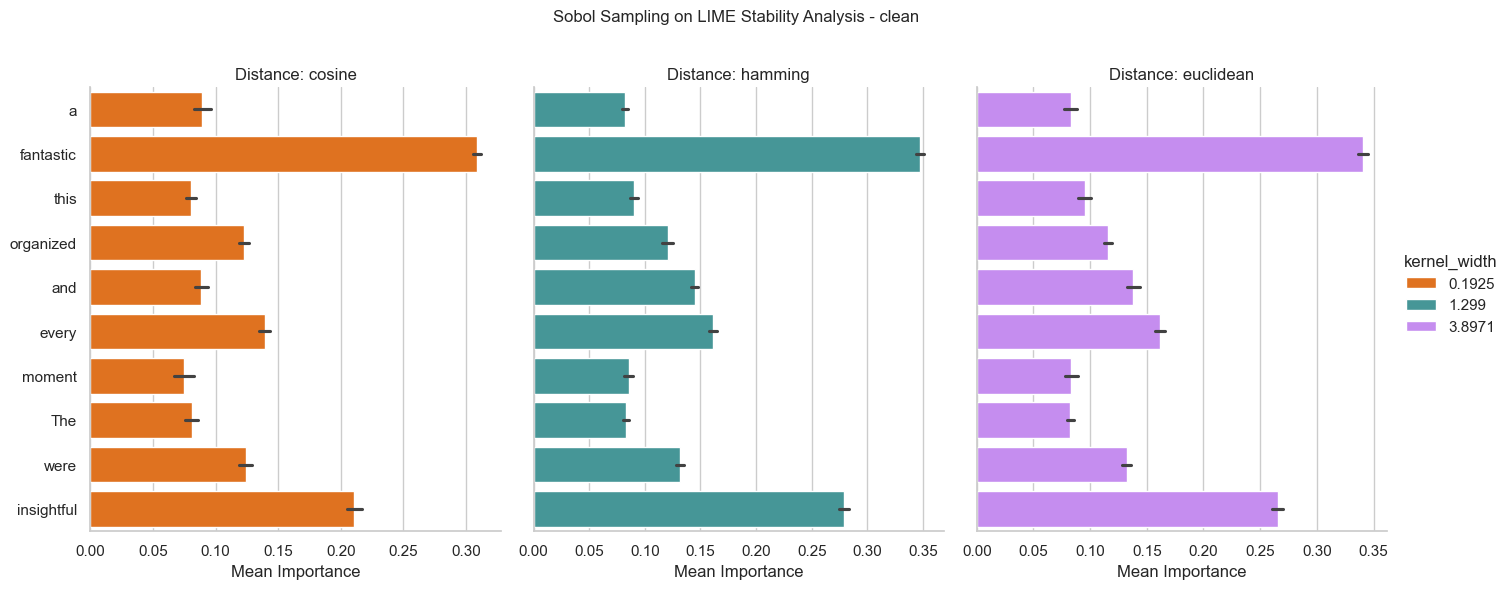

In [211]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_sobol = pd.read_csv("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_sobol_sampling_kernel_results.csv")

# Calculate Absolute Importance for ranking
df_sobol['abs_importance'] = df_sobol['importance'].abs()

# Get top 10 most influential words overall
top_words = df_sobol.groupby('word')['abs_importance'].mean().nlargest(10).index
df_plot = df_sobol[df_sobol['word'].isin(top_words)]

# Create a FacetGrid to compare Metrics
plt.figure(figsize=(14, 8))

sns.set_theme(style="whitegrid")
colors = ['#ff6d00','#38a3a5','#c77dff']
# Use a PointPlot or BarPlot with error bars to show stability
g = sns.catplot(
    data=df_plot,
    kind="bar",
    x="abs_importance",
    y="word",
    hue="kernel_width", # Compare metrics side-by-side
    col="metric", # Give each metric its own subplot
    errorbar="sd", # SHOWS STABILITY: Standard Deviation of the 10 iterations
    palette= colors,
    height=6,
    aspect=0.8,
    sharex=False
)

g.set_axis_labels("Mean Importance", "")
g.set_titles("Distance: {col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Sobol Sampling on LIME Stability Analysis - clean", fontsize=12)
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/lime_sobol_stability_experiment.png")
plt.show()



<Figure size 1400x800 with 0 Axes>

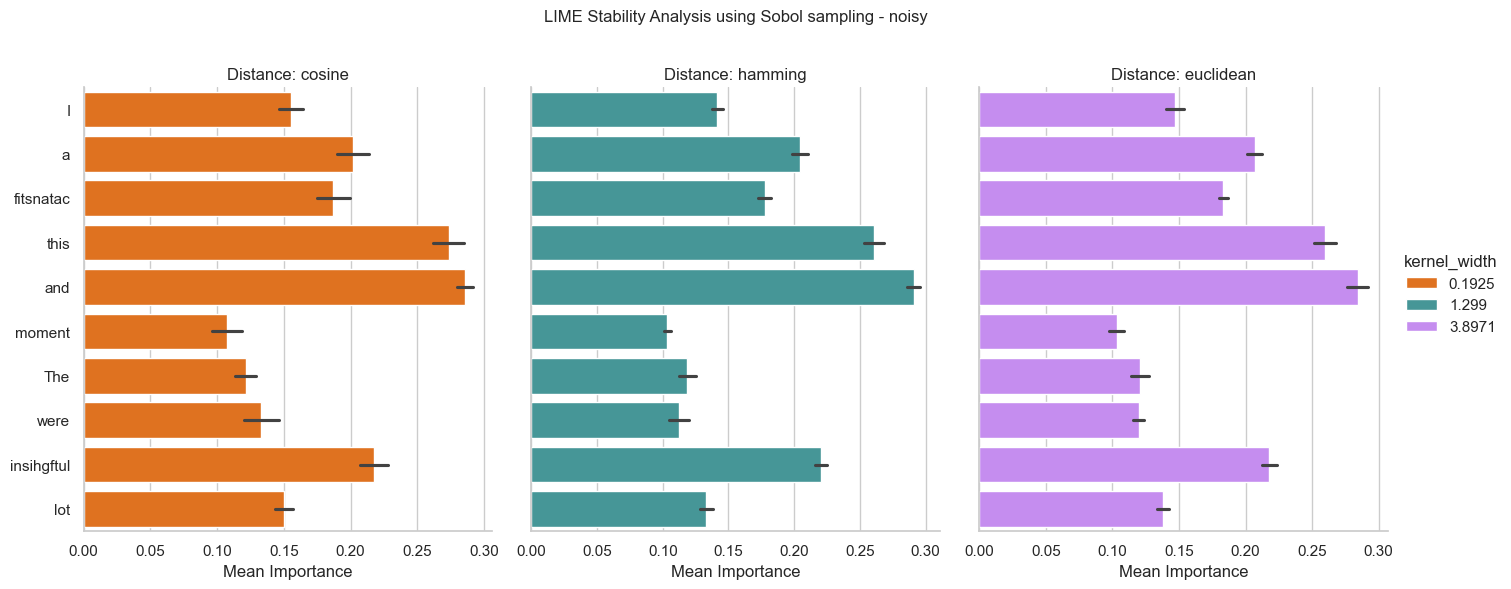

In [212]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load  data
df_sobol = pd.read_csv("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_perturb_sobol_sampling_kernel_results.csv")

# Calculate Absolute Importance for ranking
df_sobol['abs_importance'] = df_sobol['importance'].abs()

# Get top 10 most influential words overall
top_words = df_sobol.groupby('word')['abs_importance'].mean().nlargest(10).index
df_plot = df_sobol[df_sobol['word'].isin(top_words)]

# Create a FacetGrid to compare Metrics
plt.figure(figsize=(14, 8))

sns.set_theme(style="whitegrid")
colors = ['#ff6d00','#38a3a5','#c77dff']

# Use a PointPlot or BarPlot with error bars to show stability
g = sns.catplot(
    data=df_plot,
    kind="bar",
    x="abs_importance",
    y="word",
    hue="kernel_width", # Compare metrics side-by-side
    col="metric", # Give each metric its own subplot
    errorbar="sd", # SHOWS STABILITY: Standard Deviation of the 10 iterations
    palette=colors,
    height=6,
    aspect=0.8,
    sharex=False
)

g.set_axis_labels("Mean Importance", "")
g.set_titles("Distance: {col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("LIME Stability Analysis using Sobol sampling - noisy", fontsize=12)

plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/perturb_lime_sobol_stability_experiment.png")
plt.show()



## LHS Sampling clean vs noise

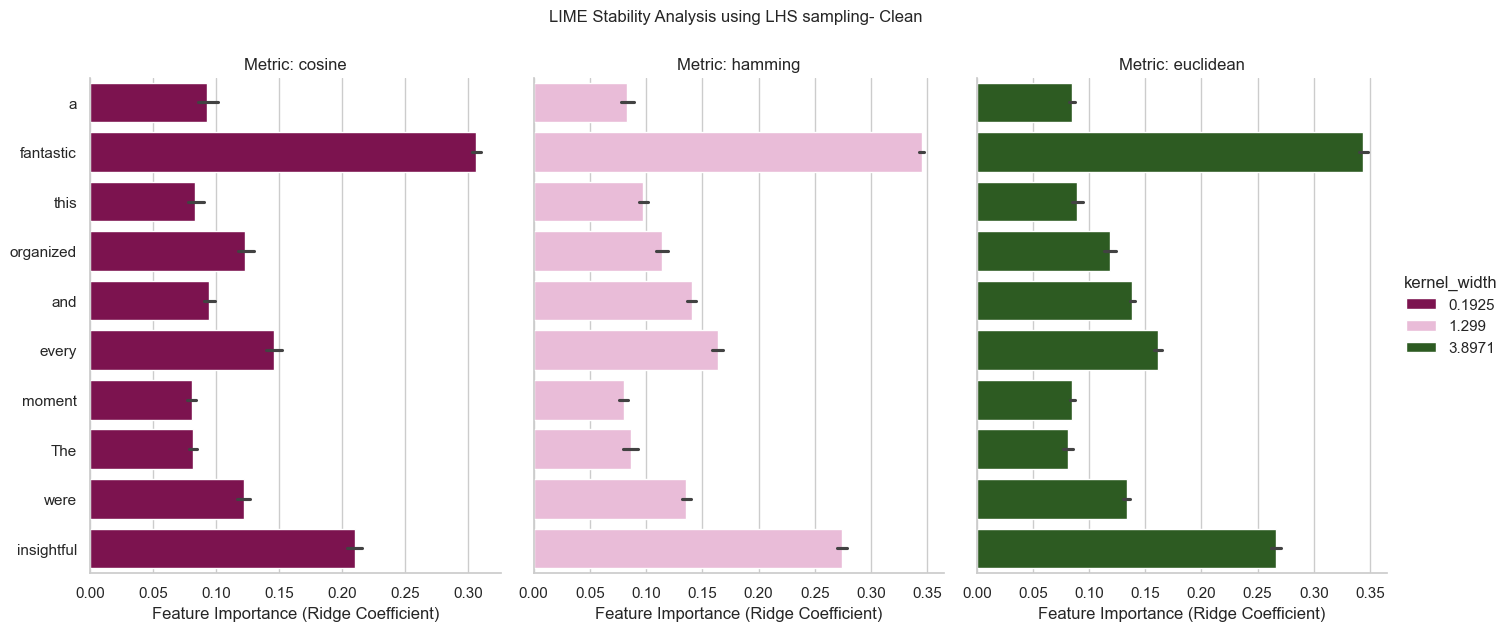

In [232]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_lhs = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_lhs_sampling_kernel_results.csv')

# Filtering for Readability
# LIME can generate many words. We'll pick the top 10 most influential
# words based on average absolute importance to keep the plot clean.
# Calculate Absolute Importance for ranking
df_lhs['abs_importance'] = df_lhs['importance'].abs()

# Get top 10 most influential words overall
top_words = df_lhs.groupby('word')['abs_importance'].mean().nlargest(10).index
df_plot = df_lhs[df_lhs['word'].isin(top_words)]

# Create the Visualization
# We use 'catplot' to create a grid: one column per Metric
sns.set_theme(style="whitegrid")
colors = ['#087e8b','#e0aaff','#ff8500']
g = sns.catplot(
    data=df_plot,
    kind="bar",
    x="abs_importance",
    y="word",
    hue="kernel_width",
    col="metric",
    palette="PiYG",
    height=6,
    aspect=0.8,
    sharex=False # Allows each metric to show its own scale if they vary wildly
)

# Customizing Labels and Titles
g.set_axis_labels("Feature Importance (Ridge Coefficient)", "")
g.set_titles("Metric: {col_name}")
g.fig.suptitle("LIME Stability Analysis using LHS sampling- Clean", y=1.05, fontsize=12)
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/lhs_stability_experiment.png")
plt.show()

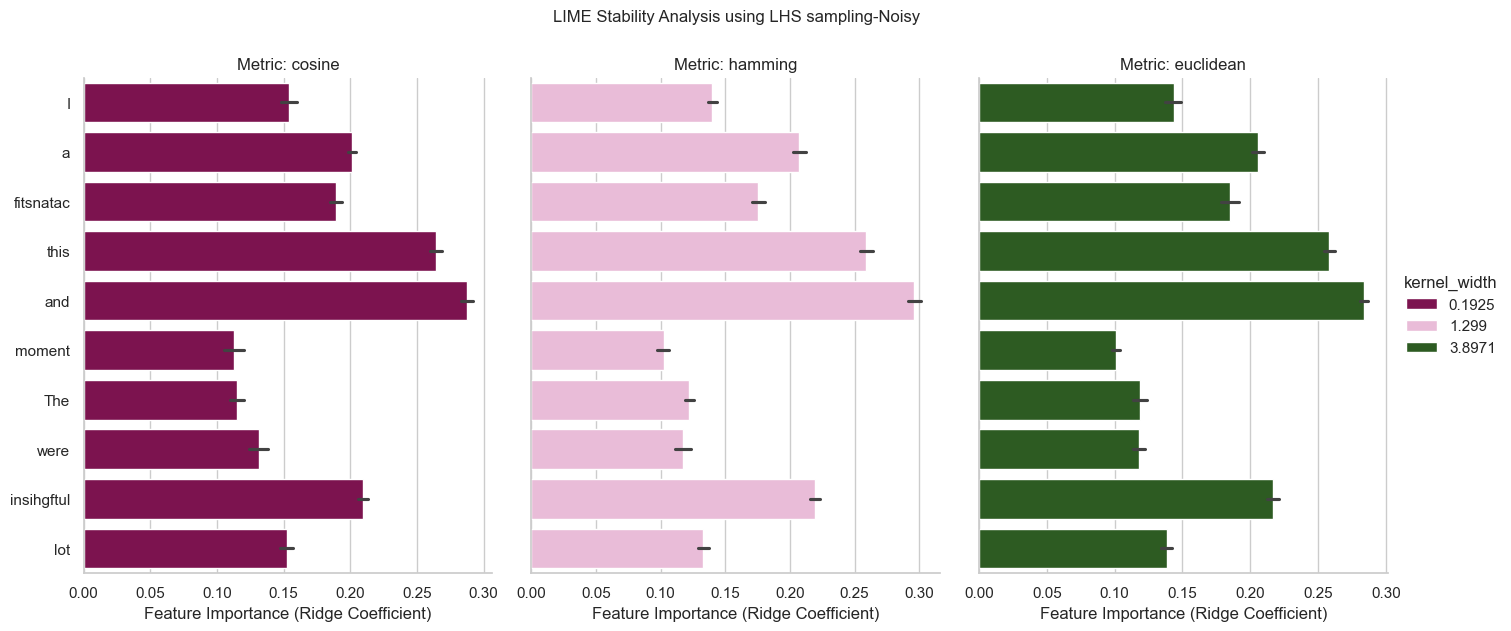

In [228]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_lhs = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_perturb_lhs_sampling_kernel_results.csv')

# calculate absolute importance for ranking
df_lhs['abs_importance'] = df_lhs['importance'].abs()

# Get top 10 most influential words overall
top_words = df_lhs.groupby('word')['abs_importance'].mean().nlargest(10).index
df_plot = df_lhs[df_sobol['word'].isin(top_words)]
# Create the Visualization
# We use 'catplot' to create a grid: one column per Metric
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_plot,
    kind="bar",
    x="abs_importance",
    y="word",
    hue="kernel_width",
    col="metric",
    palette="PiYG",
    height=6,
    aspect=0.8,
    sharex=False # Allows each metric to show its own scale if they vary wildly
)

# Customizing Labels and Titles
g.set_axis_labels("Feature Importance (Ridge Coefficient)", "")
g.set_titles("Metric: {col_name}")
g.fig.suptitle("LIME Stability Analysis using LHS sampling-Noisy", y=1.05, fontsize=12)
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/perturb_lhs_stability_experiment.png")
plt.show()

Surrogate type

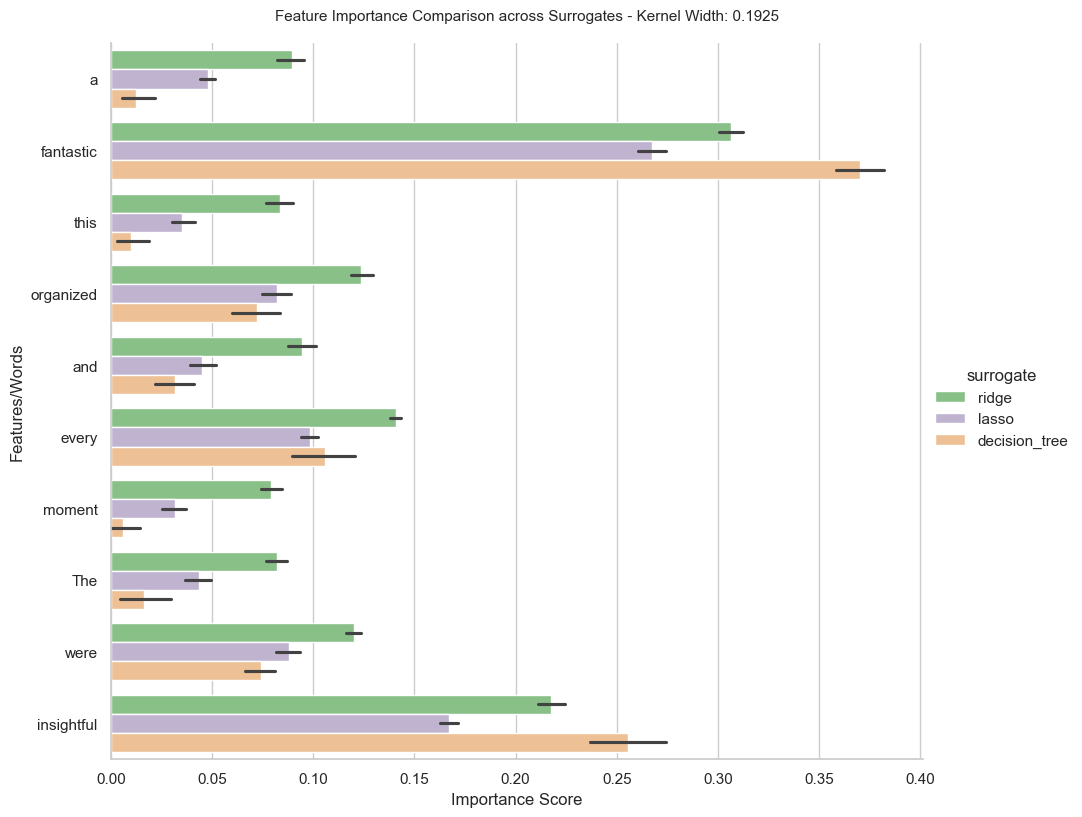

In [221]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load  data
df_surrogates_clean = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_surrogates_kernel_results.csv')


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregation and Filtering
# calculate absolute importance for ranking
df_surrogates_clean['abs_importance'] = df_surrogates_clean['importance'].abs()

# Get top 10 most influential words overall
top_words = df_surrogates_clean.groupby('word')['abs_importance'].mean().nlargest(10).index
df_plot = df_surrogates_clean[df_surrogates_clean['word'].isin(top_words)]

# Visualization
sns.set_theme(style="whitegrid")

# sns.catplot returns a FacetGrid object (g), not a standard Axes object
g = sns.catplot(
    data=df_plot,
    kind='bar',
    x='abs_importance',    # Horizontal bars (swap x and y for vertical)
    y='word',
    hue='surrogate',
    height=8,
    aspect=1.2,
    palette='Accent',
    legend=True        # Built-in legend handling
)

# Customizing the plot via the FacetGrid 'g'
kernel_val = df_surrogates_clean['kernel_width'].iloc[0]

g.set_axis_labels("Importance Score", "Features/Words")
g.fig.suptitle(f'Feature Importance Comparison across Surrogates - Kernel Width: {kernel_val}',
               fontsize=11, y=1.02)

plt.xticks(rotation=0)
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/surrogate_stability_experiment.png")
plt.show()

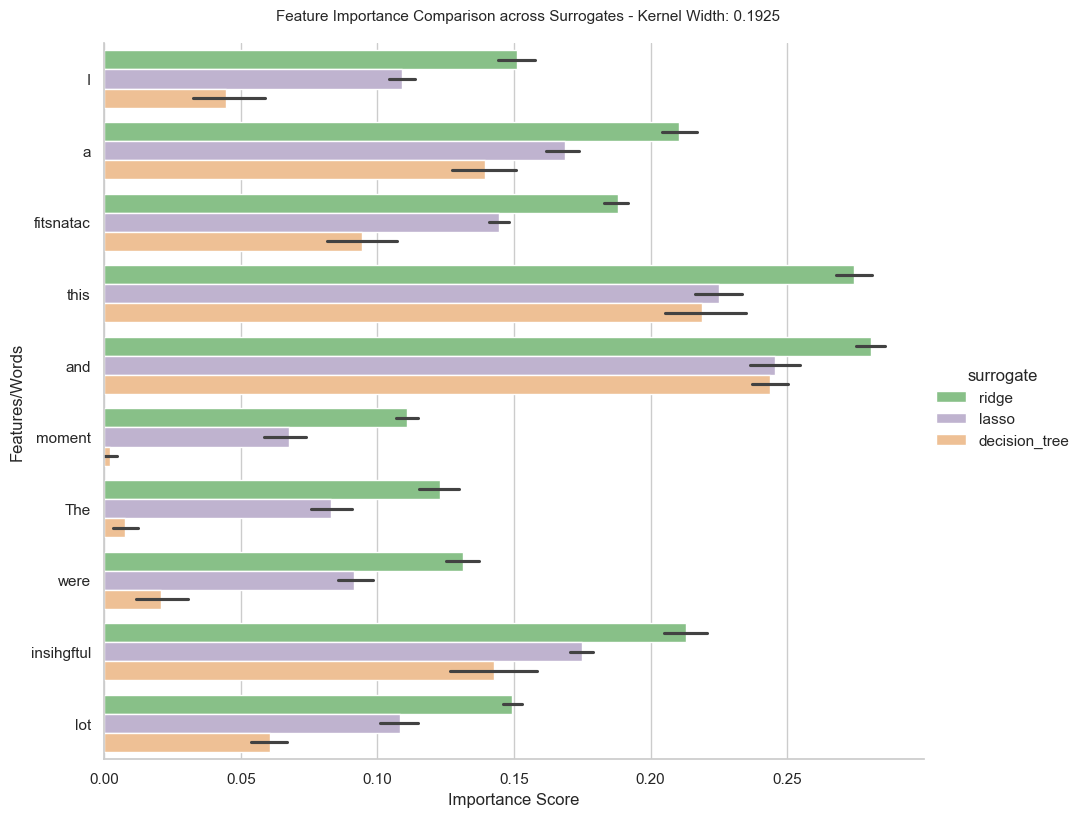

In [233]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_surrogates_noisy = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_perturb_surrogates_kernel_results.csv')

# calculate absolute importance for ranking
df_surrogates_noisy['abs_importance'] = df_surrogates_noisy['importance'].abs()

# Get top 10 most influential words overall
top_words = df_surrogates_noisy.groupby('word')['abs_importance'].mean().nlargest(10).index
df_plot = df_surrogates_noisy[df_surrogates_noisy['word'].isin(top_words)]


# Visualization
sns.set_theme(style="whitegrid")

# sns.catplot returns a FacetGrid object (g), not a standard Axes object
g = sns.catplot(
    data=df_plot,
    kind='bar',
    x='abs_importance',    # Horizontal bars (swap x and y for vertical)
    y='word',
    hue='surrogate',
    height=8,
    aspect=1.2,
    palette='Accent',
    legend=True        # Built-in legend handling
)

# Customizing the plot via the FacetGrid 'g'
kernel_val = df_surrogates_noisy['kernel_width'].iloc[0]

g.set_axis_labels("Importance Score", "Features/Words")
g.fig.suptitle(f'Feature Importance Comparison across Surrogates - Kernel Width: {kernel_val}',
               fontsize=11, y=1.02)

# If you want to rotate labels (though less necessary for horizontal bars):
plt.xticks(rotation=0)
plt.savefig("/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/results/pert_surrogate_stability_experiment.png")
plt.show()

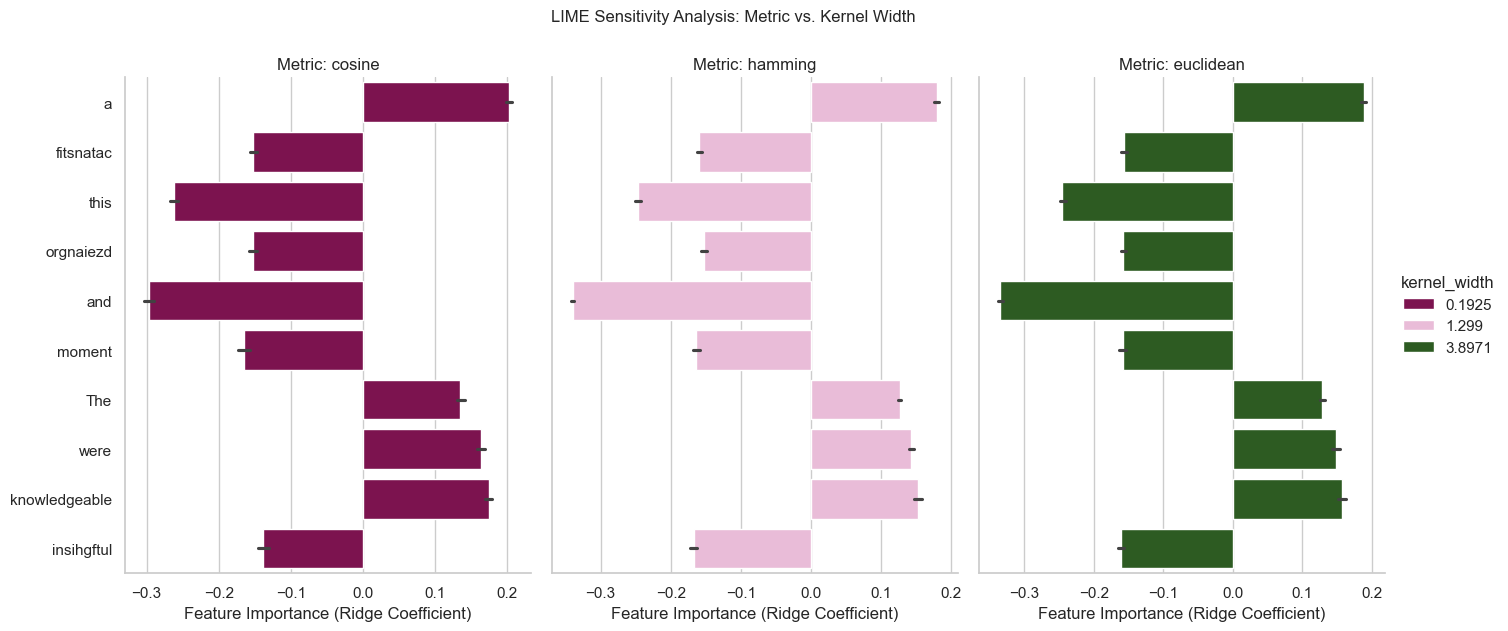

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df_lhs = pd.read_csv('/Users/oumaymabamoh/Desktop/thesis-evaluation-synthetic-data-lime-nlp/outputs/lime/lime_perturb_lhs_sampling_kernel_results.csv')

# 2. Filtering for Readability
# LIME can generate many words. We'll pick the top 10 most influential
# words based on average absolute importance to keep the plot clean.
top_words = (
    df_lhs.groupby('word')['importance']
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=False)
    .head(10)
    .index
)
df_filtered = df_lhs[df_lhs['word'].isin(top_words)]

# 3. Create the Visualization
# We use 'catplot' to create a grid: one column per Metric
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_filtered,
    kind="bar",
    x="importance",
    y="word",
    hue="kernel_width",
    col="metric",
    palette="PiYG",
    height=6,
    aspect=0.8,
    sharex=False # Allows each metric to show its own scale if they vary wildly
)

# 4. Customizing Labels and Titles
g.set_axis_labels("Feature Importance (Ridge Coefficient)", "")
g.set_titles("Metric: {col_name}")
g.fig.suptitle("LIME Sensitivity Analysis: Metric vs. Kernel Width", y=1.05, fontsize=12)

plt.show()

